In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.summarize as cs
import cortico_cereb_connectivity.globals as gl
import nibabel as nb
import Functional_Fusion.atlas_map as am
import SUITPy as suit

In [8]:
traindata = gl.traindata_string()
X = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cortex.pscalar.nii").get_fdata()
Y = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cerebellum.dscalar.nii").get_fdata()

In [9]:
# yeo details
yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_Icosahedron1002.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
label_dict = yeo_img.header.get_axis(0).label[0]
atlas,ainf = am.get_atlas('MNISymC3')

In [23]:
network = 'LimbicB'
ind = next(k for k, v in label_dict.items() if network in v[0])
print(f"Index of {network}: {ind}")
X_net = X[:, yeo_data == ind]

Index of LimbicB: 10


In [36]:
# should already be zero mean
A = X_net - X_net.mean(axis=0, keepdims=True)
B = Y - Y.mean(axis=0, keepdims=True)

A /= np.linalg.norm(A, axis=0, keepdims=True)
B /= np.linalg.norm(B, axis=0, keepdims=True)

corr = A.T @ B
print(corr.shape)

(75, 5446)


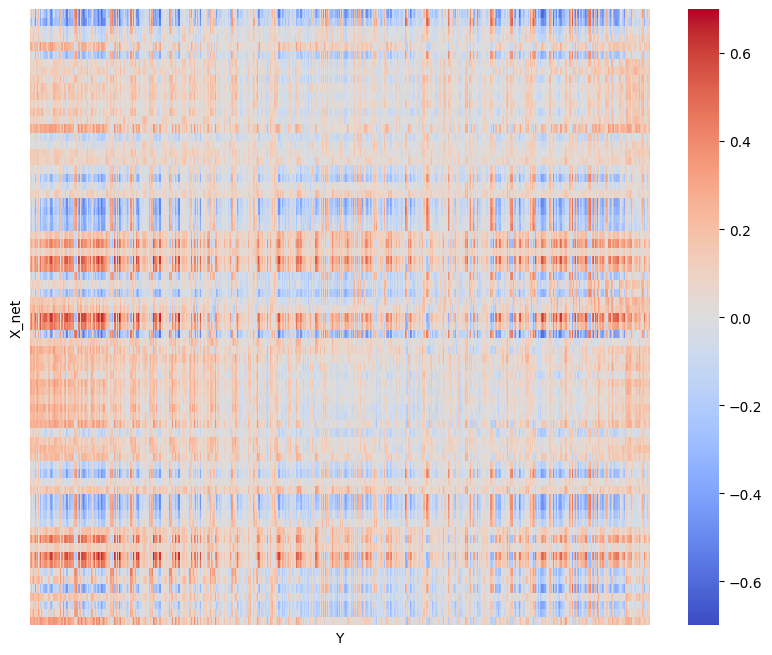

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', vmin=-0.7, vmax=0.7, center=0, xticklabels=False, yticklabels=False)
plt.xlabel('Y')
plt.ylabel('X_net');

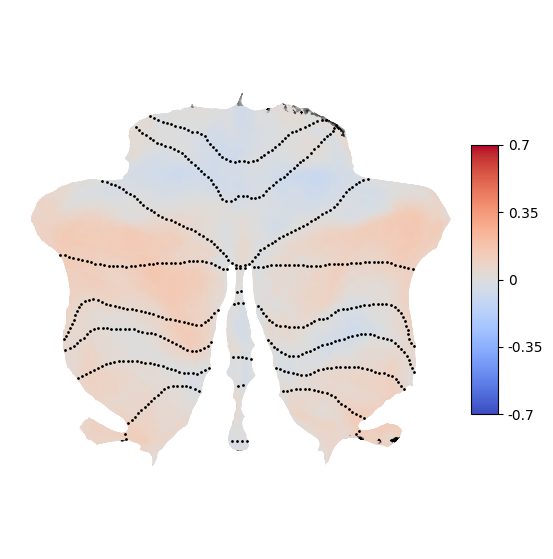

In [45]:
# plot average inner product for voxels
mean_corr = corr.mean(axis=0).squeeze()
nifti_image = atlas.data_to_nifti(mean_corr)
data = suit.vol_to_surf(nifti_image, space='MNISymC')
suit.flatmap.plot(data, cmap='coolwarm', cscale=[-0.7, 0.7], colorbar=True);